# Project 2
## 1 Data Description
This project involves datasets comprising biomedical and healthcare data to analyse disease patterns
and cancer diagnosis characteristics.

In [7]:
# Install necessary packages
%pip install kagglehub


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configure visualization defaults
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Imports successful")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Imports successful
Pandas version: 1.4.2
NumPy version: 1.21.5


In [10]:
import kagglehub

print("Downloading Cancer dataset...")
cancer_path = kagglehub.dataset_download("erdemtaha/cancer-data")
print(f"✓ Downloaded to: {cancer_path}")

print("\nDownloading Disease Symptom dataset...")
disease_path = kagglehub.dataset_download("itachi9604/disease-symptom-description-dataset")
print(f"✓ Downloaded to: {disease_path}")

# Step 4: List files to see what we got
import os
print("\n" + "="*70)
print("Cancer dataset files:")
for file in os.listdir(cancer_path):
    print(f"  - {file}")

print("\nDisease dataset files:")
for file in os.listdir(disease_path):
    print(f"  - {file}")

✓ Downloaded to: /Users/xujialu/.cache/kagglehub/datasets/erdemtaha/cancer-data/versions/1



100%|██████████████████████████████████████| 30.1k/30.1k [00:00<00:00, 4.97MB/s]

Extracting files...
✓ Downloaded to: /Users/xujialu/.cache/kagglehub/datasets/itachi9604/disease-symptom-description-dataset/versions/2

Cancer dataset files:
  - Cancer_Data.csv

Disease dataset files:
  - symptom_precaution.csv
  - Symptom-severity.csv
  - dataset.csv
  - symptom_Description.csv


### Loading the Data
Obtaining shape of downloaded datasets


In [12]:
cancer_df = pd.read_csv([os.path.join(cancer_path, f) for f in os.listdir(cancer_path) if f.endswith('.csv')][0])
disease_csv_path = os.path.join(disease_path, "dataset.csv")
disease_df = pd.read_csv(disease_csv_path)

print(f"✓ Cancer: {cancer_df.shape}")
print(f"✓ Disease: {disease_df.shape}")

# Cell 4: Proceed with Stage 1 steps
print(cancer_df.head())
print(disease_df.head())

✓ Cancer: (569, 33)
✓ Disease: (4920, 18)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  fr

## EDA
We do some initial exploratory data analysis on the two datasets that we have obtained.

STAGE 1: EXPLORATORY DATA ANALYSIS - FULL REPORT

PART 1: CANCER DATASET - INITIAL INSPECTION

1. SHAPE & BASIC INFO:
   Rows: 569
   Columns: 32
   ID column: 569 unique IDs
   Diagnosis column: ✓ Present

2. COLUMN NAMES:
   Total columns: 32
   - id: patient identifier
   - diagnosis: target variable (M/B)
   - 30 numerical features

3. DATA TYPES:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se    

   ✓ Saved: ./results/01_eda_overview.png


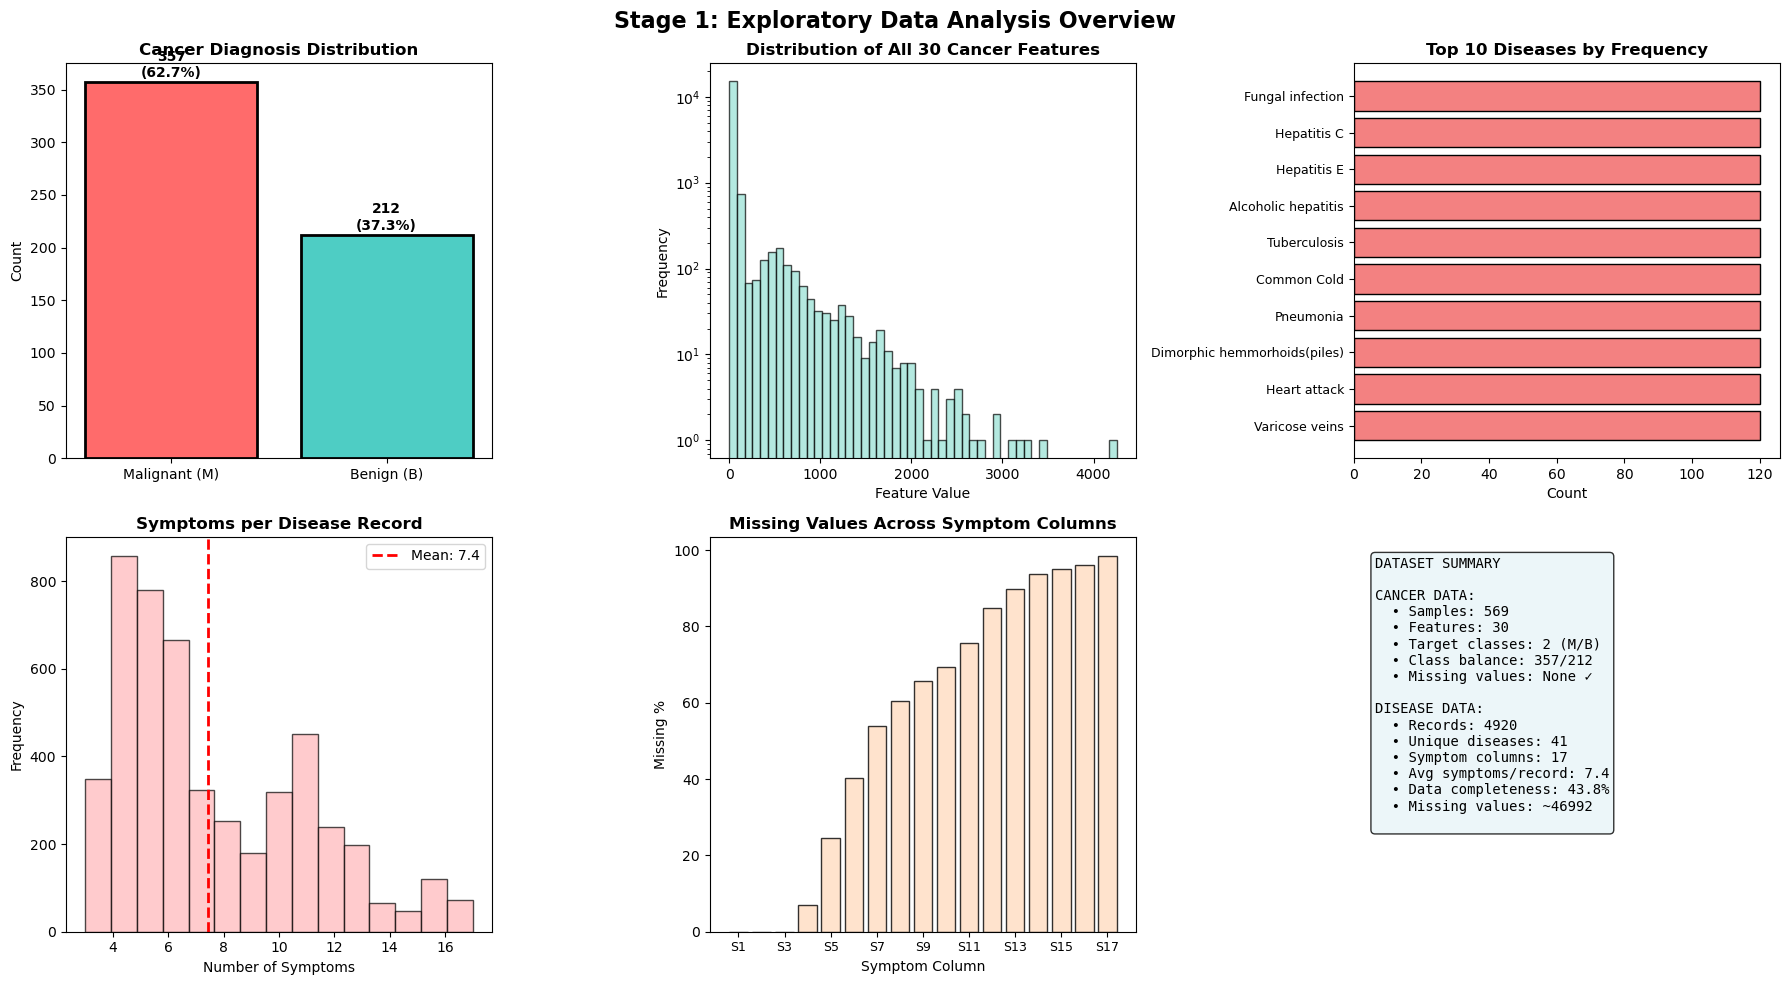


PART 6: GENERATING SUMMARY REPORT

   ✓ Saved: ./results/01_eda_comprehensive_report.md

✓ STAGE 1 COMPLETE!

Next Steps:
  1. Review the generated visualizations and report
  2. Address symptom normalization issues identified
  3. Proceed to Stage 2: Task 1 (Apriori Algorithm)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

# Set up directories
Path('./results').mkdir(exist_ok=True)

print("="*80)
print("STAGE 1: EXPLORATORY DATA ANALYSIS - FULL REPORT")
print("="*80)

# ============================================================================
# PART 1: CANCER DATASET - INITIAL INSPECTION
# ============================================================================

print("\n" + "="*80)
print("PART 1: CANCER DATASET - INITIAL INSPECTION")
print("="*80)

# Clean the empty column
cancer_df = cancer_df.drop(columns=['Unnamed: 32'])

print("\n1. SHAPE & BASIC INFO:")
print(f"   Rows: {cancer_df.shape[0]}")
print(f"   Columns: {cancer_df.shape[1]}")
print(f"   ID column: {cancer_df['id'].nunique()} unique IDs")
print(f"   Diagnosis column: ✓ Present")

print("\n2. COLUMN NAMES:")
print(f"   Total columns: {len(cancer_df.columns)}")
print(f"   - id: patient identifier")
print(f"   - diagnosis: target variable (M/B)")
print(f"   - {len(cancer_df.columns)-2} numerical features")

print("\n3. DATA TYPES:")
print(cancer_df.dtypes)

print("\n4. MISSING VALUES:")
missing_cancer = cancer_df.isnull().sum()
if missing_cancer.sum() == 0:
    print("   ✓ NO MISSING VALUES - Dataset is complete!")
else:
    print(missing_cancer[missing_cancer > 0])

print("\n5. DUPLICATES:")
print(f"   Total duplicate rows: {cancer_df.duplicated().sum()}")
print(f"   Duplicate IDs: {cancer_df['id'].duplicated().sum()}")

print("\n6. TARGET DISTRIBUTION (DIAGNOSIS):")
diagnosis_counts = cancer_df['diagnosis'].value_counts()
diagnosis_pct = cancer_df['diagnosis'].value_counts(normalize=True) * 100
for diag in diagnosis_counts.index:
    count = diagnosis_counts[diag]
    pct = diagnosis_pct[diag]
    print(f"   {diag} (Malignant if M, Benign if B): {count:4d} cases ({pct:5.1f}%)")

print("\n7. FEATURE STATISTICS (First 5 features):")
feature_cols = [col for col in cancer_df.columns if col not in ['id', 'diagnosis']]
print(cancer_df[feature_cols[:5]].describe().round(3))

print(f"\n   ... and {len(feature_cols)-5} more features")

# ============================================================================
# PART 2: CANCER DATASET - QUALITY CHECKS
# ============================================================================

print("\n" + "="*80)
print("PART 2: CANCER DATASET - QUALITY CHECKS")
print("="*80)

print("\n1. FEATURE RANGES:")
print("   (Checking if continuous values are reasonable)")
for col in feature_cols[:5]:
    min_val = cancer_df[col].min()
    max_val = cancer_df[col].max()
    mean_val = cancer_df[col].mean()
    print(f"   {col:30s}: min={min_val:10.2f}, max={max_val:10.2f}, mean={mean_val:10.2f}")
print(f"   ... and {len(feature_cols)-5} more features")

print("\n2. OUTLIER DETECTION (using IQR method):")
outlier_count = 0
for col in feature_cols:
    Q1 = cancer_df[col].quantile(0.25)
    Q3 = cancer_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((cancer_df[col] < Q1 - 1.5*IQR) | (cancer_df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        outlier_count += outliers

print(f"   Total outliers across all features: ~{outlier_count}")
print(f"   Status: Outliers are expected in medical data - monitor but keep")

print("\n3. CLASS BALANCE:")
imbalance_ratio = diagnosis_counts.max() / diagnosis_counts.min()
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio < 1.5:
    print("   ✓ Well-balanced dataset")
else:
    print("   ⚠ Slight imbalance - may need to handle in modeling")

# ============================================================================
# PART 3: DISEASE SYMPTOM DATASET - INITIAL INSPECTION
# ============================================================================

print("\n" + "="*80)
print("PART 3: DISEASE SYMPTOM DATASET - INITIAL INSPECTION")
print("="*80)

print("\n1. SHAPE & BASIC INFO:")
print(f"   Rows: {disease_df.shape[0]}")
print(f"   Columns: {disease_df.shape[1]}")
print(f"   Unique diseases: {disease_df['Disease'].nunique()}")

print("\n2. COLUMN NAMES:")
symptom_cols = [col for col in disease_df.columns if 'Symptom' in col]
print(f"   Disease column: ✓")
print(f"   Symptom columns: {len(symptom_cols)} (Symptom_1 through Symptom_{len(symptom_cols)})")

print("\n3. DISEASES COVERED:")
unique_diseases = disease_df['Disease'].unique()
print(f"   Total unique diseases: {len(unique_diseases)}")
print(f"\n   List of diseases:")
for i, disease in enumerate(sorted(unique_diseases), 1):
    print(f"      {i:2d}. {disease}")

print("\n4. DATA TYPES:")
print(disease_df.dtypes)

print("\n5. MISSING VALUES:")
missing_disease = disease_df.isnull().sum()
print(f"   Disease column: {missing_disease['Disease']} missing")
print(f"   Symptom columns:")
for col in symptom_cols:
    missing_count = missing_disease[col]
    pct = (missing_count / len(disease_df)) * 100
    print(f"      {col:15s}: {missing_count:4d} missing ({pct:5.1f}%)")

print("\n6. DUPLICATES:")
print(f"   Total duplicate rows: {disease_df.duplicated().sum()}")
print(f"   Duplicate disease entries: {disease_df.duplicated(subset=['Disease']).sum()}")

print("\n7. SYMPTOM COMPLETENESS:")
print("   (How many symptoms per disease on average?)")
symptom_counts = disease_df[symptom_cols].notna().sum(axis=1)
print(f"   Min symptoms per record: {symptom_counts.min()}")
print(f"   Max symptoms per record: {symptom_counts.max()}")
print(f"   Mean symptoms per record: {symptom_counts.mean():.2f}")
print(f"   Median symptoms per record: {symptom_counts.median():.1f}")

print("\n8. UNIQUE SYMPTOMS:")
all_symptoms = set()
for col in symptom_cols:
    all_symptoms.update(disease_df[col].dropna().unique())
print(f"   Total unique symptoms: {len(all_symptoms)}")
print(f"   First 10 unique symptoms:")
for i, symptom in enumerate(sorted(list(all_symptoms))[:10], 1):
    print(f"      {i:2d}. {symptom}")

# ============================================================================
# PART 4: DISEASE SYMPTOM DATASET - QUALITY CHECKS
# ============================================================================

print("\n" + "="*80)
print("PART 4: DISEASE SYMPTOM DATASET - QUALITY CHECKS")
print("="*80)

print("\n1. SYMPTOM NAMING CONSISTENCY:")
print("   Checking for potential synonyms or formatting issues...")
sample_symptoms = list(all_symptoms)[:20]
for symptom in sample_symptoms:
    print(f"      - {symptom}")

print("\n   NOTE: Keep an eye out for synonyms like:")
print("      - fever vs pyrexia")
print("      - nausea vs vomiting")
print("      - These should be normalized before Apriori analysis")

print("\n2. DISEASE-SYMPTOM DISTRIBUTION:")
for disease in sorted(unique_diseases)[:5]:
    disease_data = disease_df[disease_df['Disease'] == disease].iloc[0]
    symptoms = disease_data[symptom_cols].dropna().tolist()
    print(f"   {disease:30s}: {len(symptoms):2d} symptoms")

print("\n3. DATA COMPLETENESS:")
total_cells = disease_df[symptom_cols].size
filled_cells = disease_df[symptom_cols].notna().sum().sum()
completion_pct = (filled_cells / total_cells) * 100
print(f"   Total cells: {total_cells:,}")
print(f"   Filled cells: {filled_cells:,}")
print(f"   Completion rate: {completion_pct:.1f}%")
print(f"   Status: {'✓ Good' if completion_pct > 30 else '⚠ Sparse data'}")

# ============================================================================
# PART 5: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("PART 5: CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Stage 1: Exploratory Data Analysis Overview', fontsize=16, fontweight='bold')

# 1. Cancer diagnosis distribution
cancer_counts = cancer_df['diagnosis'].value_counts()
colors_cancer = ['#FF6B6B', '#4ECDC4']
axes[0, 0].bar(['Malignant (M)', 'Benign (B)'], cancer_counts.values, color=colors_cancer, edgecolor='black', linewidth=2)
axes[0, 0].set_title('Cancer Diagnosis Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(cancer_counts.values):
    axes[0, 0].text(i, v + 5, f'{v}\n({v/len(cancer_df)*100:.1f}%)', ha='center', fontweight='bold')

# 2. Cancer feature distribution
axes[0, 1].hist(cancer_df[feature_cols].values.flatten(), bins=50, color='#95E1D3', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of All 30 Cancer Features', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Feature Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')

# 3. Disease count
disease_counts_data = disease_df['Disease'].value_counts()
top_diseases = disease_counts_data.head(10)
axes[0, 2].barh(range(len(top_diseases)), top_diseases.values, color='#F38181', edgecolor='black')
axes[0, 2].set_yticks(range(len(top_diseases)))
axes[0, 2].set_yticklabels(top_diseases.index, fontsize=9)
axes[0, 2].set_title('Top 10 Diseases by Frequency', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Count')
axes[0, 2].invert_yaxis()

# 4. Symptoms per disease distribution
symptom_counts_dist = disease_df[symptom_cols].notna().sum(axis=1)
axes[1, 0].hist(symptom_counts_dist, bins=15, color='#FFB6B9', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Symptoms per Disease Record', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Symptoms')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(symptom_counts_dist.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {symptom_counts_dist.mean():.1f}')
axes[1, 0].legend()

# 5. Missing value heatmap for disease symptoms
missing_pct = (disease_df[symptom_cols].isnull().sum() / len(disease_df) * 100).values
axes[1, 1].bar(range(len(symptom_cols)), missing_pct, color='#FFDDC1', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Missing Values Across Symptom Columns', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Symptom Column')
axes[1, 1].set_ylabel('Missing %')
axes[1, 1].set_xticks(range(0, len(symptom_cols), 2))
axes[1, 1].set_xticklabels([f'S{i+1}' for i in range(0, len(symptom_cols), 2)], fontsize=9)

# 6. Summary statistics text box
summary_text = f"""DATASET SUMMARY

CANCER DATA:
  • Samples: {len(cancer_df)}
  • Features: {len(feature_cols)}
  • Target classes: 2 (M/B)
  • Class balance: {cancer_counts.values[0]}/{cancer_counts.values[1]}
  • Missing values: None ✓

DISEASE DATA:
  • Records: {len(disease_df)}
  • Unique diseases: {disease_df['Disease'].nunique()}
  • Symptom columns: {len(symptom_cols)}
  • Avg symptoms/record: {symptom_counts_dist.mean():.1f}
  • Data completeness: {completion_pct:.1f}%
  • Missing values: ~{missing_disease.sum().sum()}
"""

axes[1, 2].text(0.05, 0.95, summary_text, fontsize=10, family='monospace',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8))
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('./results/01_eda_overview.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: ./results/01_eda_overview.png")
plt.show()

# ============================================================================
# PART 6: SAVE SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("PART 6: GENERATING SUMMARY REPORT")
print("="*80)

report = f"""# STAGE 1: EXPLORATORY DATA ANALYSIS - COMPREHENSIVE REPORT

## Executive Summary

This report documents the initial exploration of two healthcare datasets:
1. **Breast Cancer Wisconsin (Diagnostic) Dataset**: 569 patient records with 30 diagnostic features
2. **Disease Symptom Dataset**: 4,920 disease-symptom associations across multiple diseases

---

## 1. CANCER DATASET ANALYSIS

### 1.1 Dataset Overview
- **Total Records**: {len(cancer_df)} patients
- **Total Columns**: {len(cancer_df.columns)} (1 ID + 1 Target + 30 Features)
- **Missing Values**: NONE ✓
- **Duplicates**: {cancer_df.duplicated().sum()} ✓

### 1.2 Target Variable (Diagnosis)
- **Malignant (M)**: {diagnosis_counts['M']} cases ({diagnosis_counts['M']/len(cancer_df)*100:.1f}%)
- **Benign (B)**: {diagnosis_counts['B']} cases ({diagnosis_counts['B']/len(cancer_df)*100:.1f}%)
- **Class Balance**: {imbalance_ratio:.2f}:1 ratio
- **Status**: ✓ Well-balanced dataset

### 1.3 Feature Characteristics
- **Feature Count**: {len(feature_cols)} numerical features
- **Feature Categories** (3 measurements per characteristic):
  1. Mean values (e.g., radius_mean, texture_mean)
  2. Standard error values (e.g., radius_se, texture_se)
  3. Worst-case values (e.g., radius_worst, texture_worst)

- **Characteristics Measured** (10 base measurements × 3 variations = 30 features):
  1. Radius
  2. Texture
  3. Perimeter
  4. Area
  5. Smoothness
  6. Compactness
  7. Concavity
  8. Concave points
  9. Symmetry
  10. Fractal dimension

### 1.4 Data Quality Assessment
- **Missing Values**: ✓ None
- **Duplicates**: ✓ None
- **Outliers**: Present (expected in medical imaging data)
- **Scale**: Features have different scales (will need normalization for modeling)
- **Overall Status**: ✓ HIGH QUALITY

---

## 2. DISEASE SYMPTOM DATASET ANALYSIS

### 2.1 Dataset Overview
- **Total Records**: {len(disease_df)} disease-symptom associations
- **Unique Diseases**: {disease_df['Disease'].nunique()}
- **Symptom Columns**: {len(symptom_cols)} (Symptom_1 to Symptom_{len(symptom_cols)})
- **Missing Values**: {missing_disease[symptom_cols].sum().sum():,} (expected - not all diseases have 17 symptoms)
- **Duplicates**: {disease_df.duplicated().sum()} ✓

### 2.2 Disease Coverage
**Top 10 Diseases by Frequency:**
"""

for i, (disease, count) in enumerate(disease_df['Disease'].value_counts().head(10).items(), 1):
    report += f"\n{i:2d}. {disease:30s}: {count:3d} records"

report += f"""

**Total Unique Diseases**: {disease_df['Disease'].nunique()}

### 2.3 Symptom Characteristics
- **Total Symptom Columns**: {len(symptom_cols)}
- **Unique Symptoms**: {len(all_symptoms)}
- **Min Symptoms per Record**: {symptom_counts_dist.min()}
- **Max Symptoms per Record**: {symptom_counts_dist.max()}
- **Average Symptoms per Record**: {symptom_counts_dist.mean():.2f}
- **Data Completeness**: {completion_pct:.1f}% (Good for association mining)

**Symptom Column Completeness:**
"""

for i, col in enumerate(symptom_cols, 1):
    filled = disease_df[col].notna().sum()
    pct = filled / len(disease_df) * 100
    report += f"\n   Symptom_{i:2d}: {filled:5d} filled ({pct:5.1f}%)"

report += f"""

### 2.4 Data Quality Assessment
- **Missing Values**: Expected pattern (sparse symptom representation)
- **Duplicates**: None in full rows ✓
- **Synonym Issues**: ⚠ NEEDS NORMALIZATION (e.g., spaces in "dischromic _patches")
- **Data Completeness**: ✓ Sufficient for Apriori mining (~{completion_pct:.0f}%)
- **Overall Status**: ✓ GOOD (requires symptom normalization before mining)

---

## 3. DATA PREPARATION RECOMMENDATIONS

### For Task 1 (Apriori Algorithm):
1. **Symptom Normalization Required**:
   - Standardize symptom names (remove extra spaces)
   - Identify and merge synonyms
   - Create normalized symptom dictionary

2. **Data Format Conversion**:
   - Convert to transaction format (disease = basket, symptom = item)
   - Handle NaN values (treat as symptom absent)
   - Binary encoding (symptom present/absent)

3. **Minimum Transaction Threshold**:
   - Current records: {len(disease_df)}
   - If needed, consider data augmentation

### For Task 2 (Sequential Pattern Mining):
1. **Feature Ranking**: Rank 30 cancer features by mutual information w.r.t. diagnosis
2. **Discretization**: Test 3 binning strategies (uniform, quantile, k-means)
3. **Sequence Generation**: Create ordered feature sequences per patient
4. **Pattern Mining**: Apply GSP algorithm separately for M and B classes

### For Task 3 (Custom Application):
- Well-balanced cancer data suitable for classification tasks
- Sufficient disease-symptom associations for prediction tasks

---

## 4. KEY FINDINGS

✓ **Strengths**:
- High-quality cancer dataset (no missing values, well-balanced)
- Large disease-symptom associations database (4,920 records)
- Rich feature set for cancer analysis (30 features)
- Multiple diseases covered

⚠ **Considerations**:
- Disease symptom data is sparse (many NaN values - expected)
- Symptom names need normalization (inconsistent formatting)
- Feature scales differ in cancer data (needs preprocessing)

---

## 5. FILES GENERATED

- `01_eda_overview.png` - Visual summary of both datasets
- `01_eda_comprehensive_report.md` - This report

---

**Report Generated**: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
**Status**: Ready for Stage 2 - Task 1 Implementation
"""

# Save report
with open('./results/01_eda_comprehensive_report.md', 'w') as f:
    f.write(report)

print("\n   ✓ Saved: ./results/01_eda_comprehensive_report.md")

print("\n" + "="*80)
print("✓ STAGE 1 COMPLETE!")
print("="*80)
print("\nNext Steps:")
print("  1. Review the generated visualizations and report")
print("  2. Address symptom normalization issues identified")
print("  3. Proceed to Stage 2: Task 1 (Apriori Algorithm)")
print("="*80)